# 1. 神经网络

① 把网络结构放在Sequential里面，好处就是代码写起来比较简介、易懂。

② 可以根据神经网络每层的尺寸，根据下图的公式计算出神经网络中的参数。

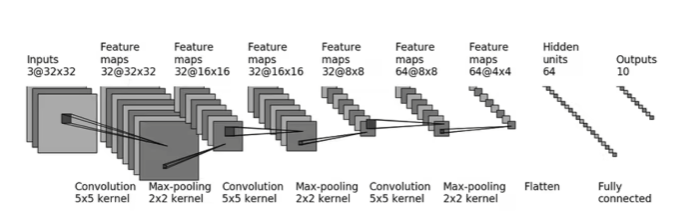

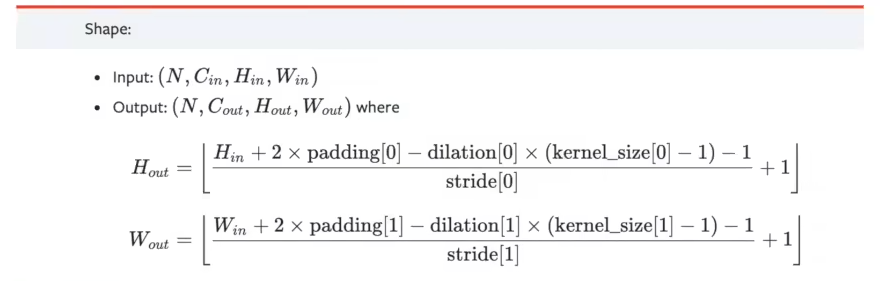

# 2. 搭建神经网络

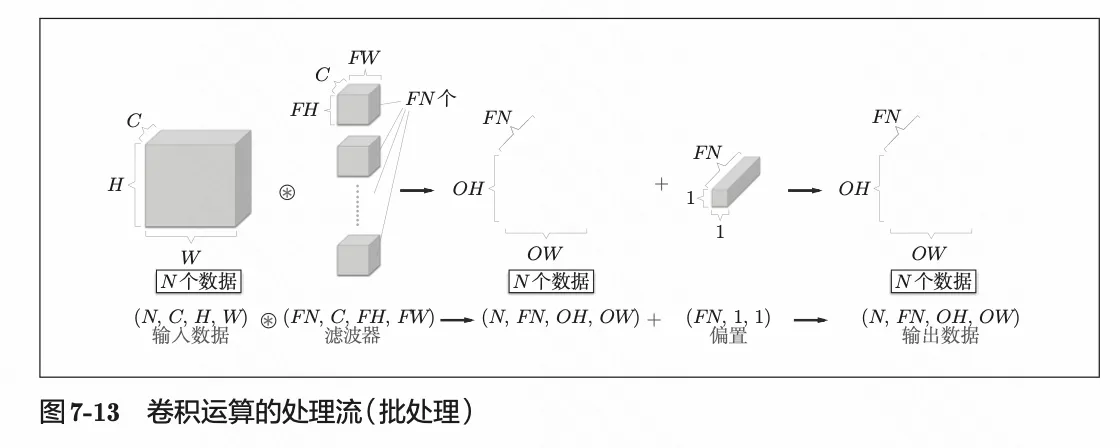

// 池化计算思路
output_size = (input_size − pool_size) / stride + 1

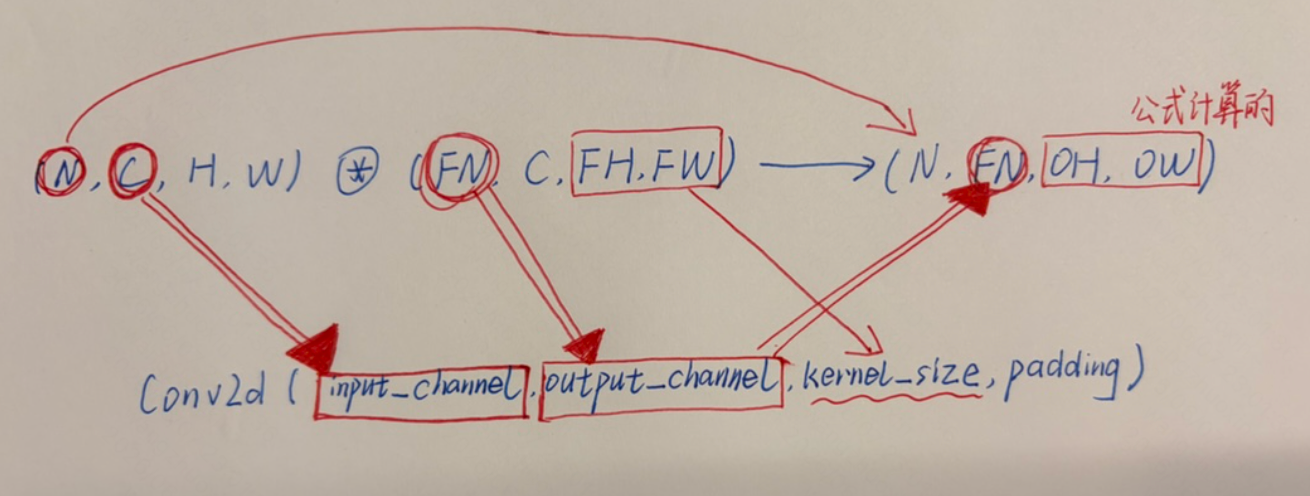

In [ ]:
import torch
import torchvision
from torch import nn 
from torch.nn import Conv2d, MaxPool2d, Flatten, Linear # 卷积、池化、展平、线性

class Tudui(nn.Module):
    def __init__(self):
        super(Tudui, self).__init__()
        """
        层	            操作	              输出形状
        输入	    -	                     [N, 3, 32, 32]
        conv1	Conv2d(3→32, 5×5, pad=2)	[N, 32, 32, 32] # batch_size=N, output_channel=FN, output_height=OH, output_width=OW
        maxpool1	MaxPool2d(2)	        [N, 32, 16, 16]
        conv2	Conv2d(32→32, 5×5, pad=2)	[N, 32, 16, 16]
        maxpool2	MaxPool2d(2)	        [N, 32, 8, 8]
        conv3	Conv2d(32→64, 5×5, pad=2)	[N, 64, 8, 8]
        maxpool3	MaxPool2d(2)	        [N, 64, 4, 4]
        flatten	Flatten()	                [N, 1024]
        linear1	Linear(1024→64)	            [N, 64]
        linear2	Linear(64→10)	            [N, 10]
        """

        # input_channel(IC)、output_channel(OC)、kernel_size、padding。输出形状：[C=3, FN=32, OH=32, OW=32]
        self.conv1 = Conv2d(3,32,5,padding=2)   

        # 还有两个可选参数 dilation=1, ceil_mode=False。用的时候再查下即可。
        self.maxpool1 = MaxPool2d(2)    # kernel_size、stride = 2。输出形状：[N, 32, 16, 16]

        self.cov2 = Conv2d(32,32,5,padding=2)
        self.maxpool2 = MaxPool2d(2)
        self.conv3 = Conv2d(32,64,5,padding=2)
        self.maxpool3 = MaxPool2d(2)
        self.flatten = Flatten()
        self.linear1 = Linear(1024,64)
        self.Linear2 = Linear(64,10)
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.maxpool1(x)
        x = self.conv2(x)
        x = self.maxpool2(x)
        x = self.conv3(x)
        x = self.maxpool3(x)
        x = self.flatten(x)
        x = self.linear1(x)
        x = self.Linear2(x)
        return x

tudui = Tudui()
print(tudui)

Tudui(
  (conv1): Conv2d(3, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (cov2): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (maxpool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear1): Linear(in_features=1024, out_features=64, bias=True)
  (Linear2): Linear(in_features=64, out_features=10, bias=True)
)


# 3. 神经网络输入数据

In [ ]:
import torch
import torchvision
from torch import nn 
from torch.nn import Conv2d, MaxPool2d, Flatten, Linear

class Tudui(nn.Module):
    def __init__(self):
        super(Tudui, self).__init__()
        self.conv1 = Conv2d(3,32,5,padding=2)
        self.maxpool1 = MaxPool2d(2)
        self.conv2 = Conv2d(32,32,5,padding=2)
        self.maxpool2 = MaxPool2d(2)
        self.conv3 = Conv2d(32,64,5,padding=2)
        self.maxpool3 = MaxPool2d(2)
        self.flatten = Flatten()
        self.linear1 = Linear(1024,64)
        self.Linear2 = Linear(64,10)
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.maxpool1(x)
        x = self.conv2(x)
        x = self.maxpool2(x)
        x = self.conv3(x)
        x = self.maxpool3(x)
        x = self.flatten(x)
        x = self.linear1(x)
        x = self.Linear2(x)
        return x

tudui = Tudui()
input = torch.ones((64,3,32,32))    # （N，C，H，W）
output = tudui(input)
print(output.shape)

torch.Size([64, 10])


# 4. Sequential神经网络

Sequential 是 PyTorch 提供的一个容器（Container），它把你写的多个神经网络层按顺序打包在一起。数据从输入进去，会自动依次流过每一层，不用你手动一层一层地传。

类比理解：就像工厂的流水线，原料（数据）从入口进去，自动经过每一道工序（层），最后从出口出来。

Sequential的好处是，forward 调用起来更加方便。



In [ ]:
import torch
import torchvision
from torch import nn 
from torch.nn import Conv2d, MaxPool2d, Flatten, Linear, Sequential

class Tudui(nn.Module):
    def __init__(self):
        super(Tudui, self).__init__()        
        self.model1 = Sequential(
            Conv2d(3,32,5,padding=2),
            MaxPool2d(2),
            Conv2d(32,32,5,padding=2),
            MaxPool2d(2),
            Conv2d(32,64,5,padding=2),
            MaxPool2d(2),
            Flatten(),
            Linear(1024,64),
            Linear(64,10)
        )
        
    def forward(self, x):
        x = self.model1(x)
        return x

tudui = Tudui()
input = torch.ones((64,3,32,32))
output = tudui(input)
print(output.shape)


"""
除此之外还能用有序字段给每层起名字：
from collections import OrderedDict

self.model1 = Sequential(OrderedDict([
    ('conv1', Conv2d(3, 32, 5, padding=2)),
    ('pool1', MaxPool2d(2)),
    ('conv2', Conv2d(32, 32, 5, padding=2)),
    ('pool2', MaxPool2d(2)),
    ('conv3', Conv2d(32, 64, 5, padding=2)),
    ('pool3', MaxPool2d(2)),
    ('flatten', Flatten()),
    ('linear1', Linear(1024, 64)),
    ('linear2', Linear(64, 10))
]))
"""

torch.Size([64, 10])


# 4. Tensorboard显示网络

In [ ]:
import torch
import torchvision
from torch import nn 
from torch.nn import Conv2d, MaxPool2d, Flatten, Linear, Sequential
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter

dataset = torchvision.datasets.CIFAR10("./dataset",train=False,transform=torchvision.transforms.ToTensor(),download=True)       
dataloader = DataLoader(dataset, batch_size=64,drop_last=True)

class Tudui(nn.Module):
    def __init__(self):
        super(Tudui, self).__init__()        
        self.model1 = Sequential(
            Conv2d(3,32,5,padding=2),
            MaxPool2d(2),
            Conv2d(32,32,5,padding=2),
            MaxPool2d(2),
            Conv2d(32,64,5,padding=2),
            MaxPool2d(2),
            Flatten(),
            Linear(1024,64),
            Linear(64,10)
        )
        
    def forward(self, x):
        x = self.model1(x)
        return x

tudui = Tudui()
writer = SummaryWriter("logs")

tudui = Tudui()
input = torch.ones((64,3,32,32))
output = tudui(input)
print(output.shape)

writer.add_graph(tudui, input)  # add_graph会追踪一次完整的前向传播，然后生成一个计算图
writer.close()

Files already downloaded and verified
torch.Size([64, 10])


① 在 Anaconda 终端里面，激活py3.6.3环境，再输入 tensorboard --logdir=C:\Users\wangy\Desktop\03CV\logs 命令，将网址赋值浏览器的网址栏，回车，即可查看tensorboard显示日志情况。

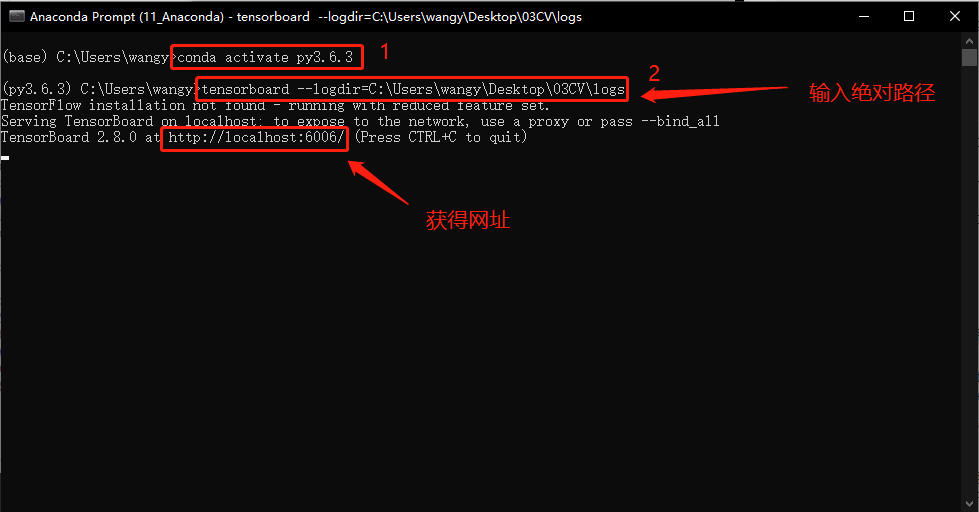

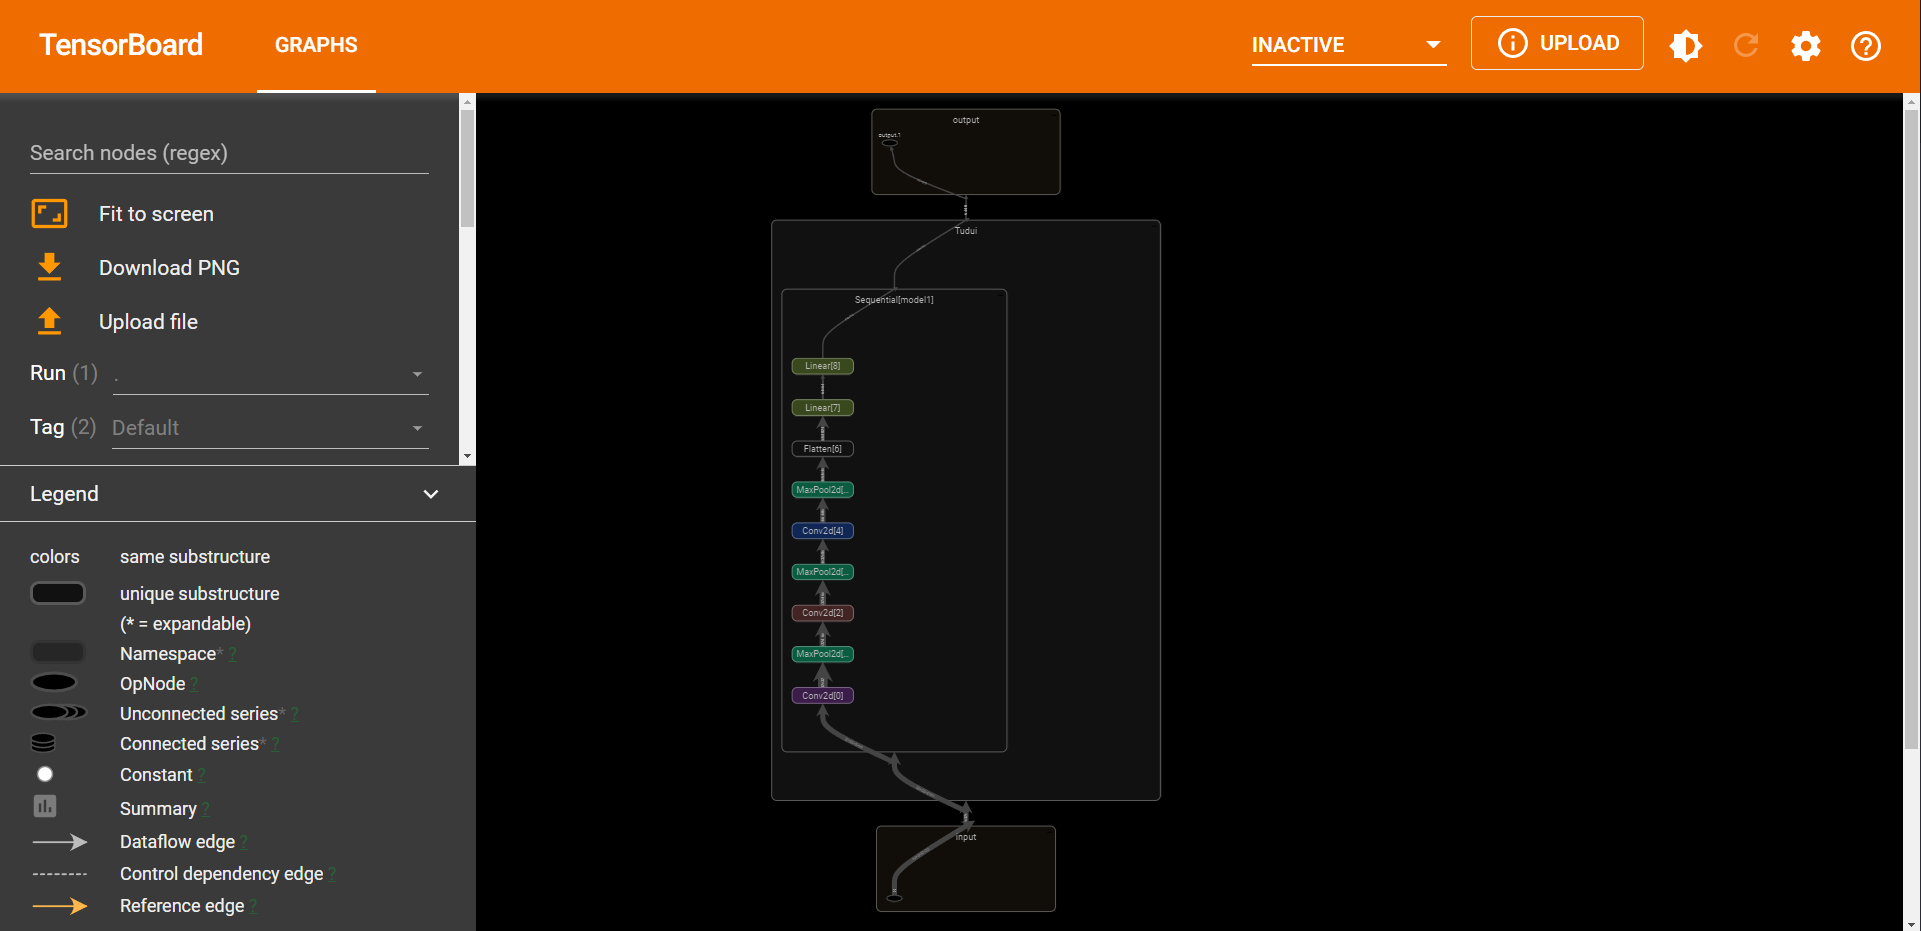